In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!nvidia-smi

Wed Aug 26 07:24:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("GPU Count:", len(gpus))

if gpus:
    print("✅ TensorFlow GPU detected")
    print("GPU:", gpus[0])
else:
    print("❌ TensorFlow GPU not detected")

TensorFlow Version: 2.20.0
GPU Count: 1
✅ TensorFlow GPU detected
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [4]:
!wget -q -O casting_dataset.zip \
"https://www.kaggle.com/api/v1/datasets/download/ravirajsinh45/real-life-industrial-dataset-of-casting-product"

print("✅ Dataset downloaded")

✅ Dataset downloaded


In [6]:
!unzip -q /content/casting_dataset.zip -d /content/casting_dataset

print("✅ Dataset extracted")

✅ Dataset extracted


In [7]:
!find /content/casting_dataset -maxdepth 3 -type d

/content/casting_dataset
/content/casting_dataset/casting_data
/content/casting_dataset/casting_data/casting_data
/content/casting_dataset/casting_data/casting_data/train
/content/casting_dataset/casting_data/casting_data/test
/content/casting_dataset/casting_512x512
/content/casting_dataset/casting_512x512/casting_512x512
/content/casting_dataset/casting_512x512/casting_512x512/def_front
/content/casting_dataset/casting_512x512/casting_512x512/ok_front


In [9]:
!find /content/casting_dataset -maxdepth 5 -type d

/content/casting_dataset
/content/casting_dataset/casting_data
/content/casting_dataset/casting_data/casting_data
/content/casting_dataset/casting_data/casting_data/train
/content/casting_dataset/casting_data/casting_data/train/def_front
/content/casting_dataset/casting_data/casting_data/train/ok_front
/content/casting_dataset/casting_data/casting_data/test
/content/casting_dataset/casting_data/casting_data/test/def_front
/content/casting_dataset/casting_data/casting_data/test/ok_front
/content/casting_dataset/casting_512x512
/content/casting_dataset/casting_512x512/casting_512x512
/content/casting_dataset/casting_512x512/casting_512x512/def_front
/content/casting_dataset/casting_512x512/casting_512x512/ok_front


In [10]:
TRAIN_PATH = "/content/casting_dataset/casting_data/casting_data/train"
TEST_PATH  = "/content/casting_dataset/casting_data/casting_data/test"

In [11]:
import os

base_path = "/content/casting_dataset"

TRAIN_PATH = None
TEST_PATH = None

for root, dirs, files in os.walk(base_path):
    if "ok_front" in dirs and "def_front" in dirs:
        if root.endswith("train"):
            TRAIN_PATH = root
        elif root.endswith("test"):
            TEST_PATH = root

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH :", TEST_PATH)

TRAIN_PATH: /content/casting_dataset/casting_data/casting_data/train
TEST_PATH : /content/casting_dataset/casting_data/casting_data/test


In [12]:
for split_name, split_path in [("Train", TRAIN_PATH), ("Test", TEST_PATH)]:
    print(f"\n{split_name} Dataset")
    print("-" * 40)

    for class_name in ["ok_front", "def_front"]:
        class_folder = os.path.join(split_path, class_name)

        count = len([
            f for f in os.listdir(class_folder)
            if os.path.isfile(os.path.join(class_folder, f))
        ])

        print(f"{class_name}: {count} images")


Train Dataset
----------------------------------------
ok_front: 2875 images
def_front: 3758 images

Test Dataset
----------------------------------------
ok_front: 262 images
def_front: 453 images


In [13]:
CLASS_NAMES = ["ok_front", "def_front"]

print("\nClass Mapping")
print("0 = ok_front  -> Non-defective")
print("1 = def_front -> Defective")


Class Mapping
0 = ok_front  -> Non-defective
1 = def_front -> Defective


In [14]:
import tensorflow as tf

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = ["ok_front", "def_front"]

print("Image Size:", IMAGE_SIZE)
print("Batch Size:", BATCH_SIZE)
print("0 = ok_front  -> Non-defective")
print("1 = def_front -> Defective")

Image Size: (224, 224)
Batch Size: 32
0 = ok_front  -> Non-defective
1 = def_front -> Defective


In [15]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=CLASS_NAMES
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_PATH,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=CLASS_NAMES
)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.


In [16]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_PATH,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    class_names=CLASS_NAMES,
    shuffle=False
)

Found 715 files belonging to 2 classes.


In [17]:
print("\nClass Names:", train_dataset.class_names)
print("Training batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Test batches:", len(test_dataset))


Class Names: ['ok_front', 'def_front']
Training batches: 166
Validation batches: 42
Test batches: 23


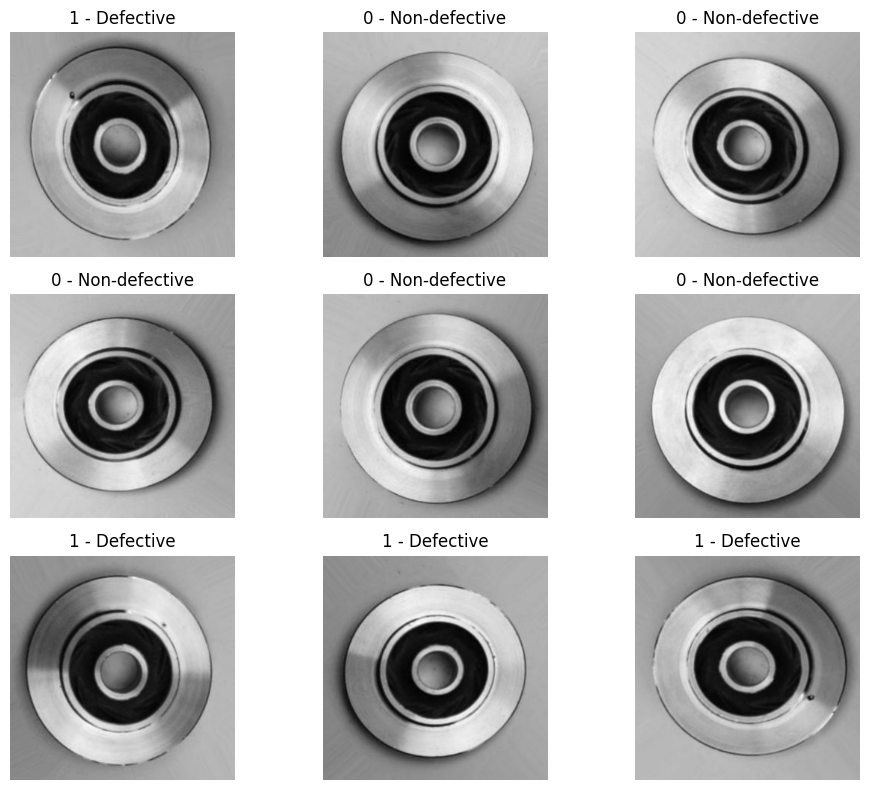

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        label = int(labels[i].numpy()[0])

        class_name = (
            "Non-defective"
            if label == 0
            else "Defective"
        )

        plt.title(
            f"{label} - {class_name}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("✅ Dataset pipeline optimized")

✅ Dataset pipeline optimized


In [20]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

print("✅ Data augmentation ready")

✅ Data augmentation ready


In [21]:
normalization_layer = layers.Rescaling(1.0 / 255)

print("✅ Normalization layer ready")

✅ Normalization layer ready


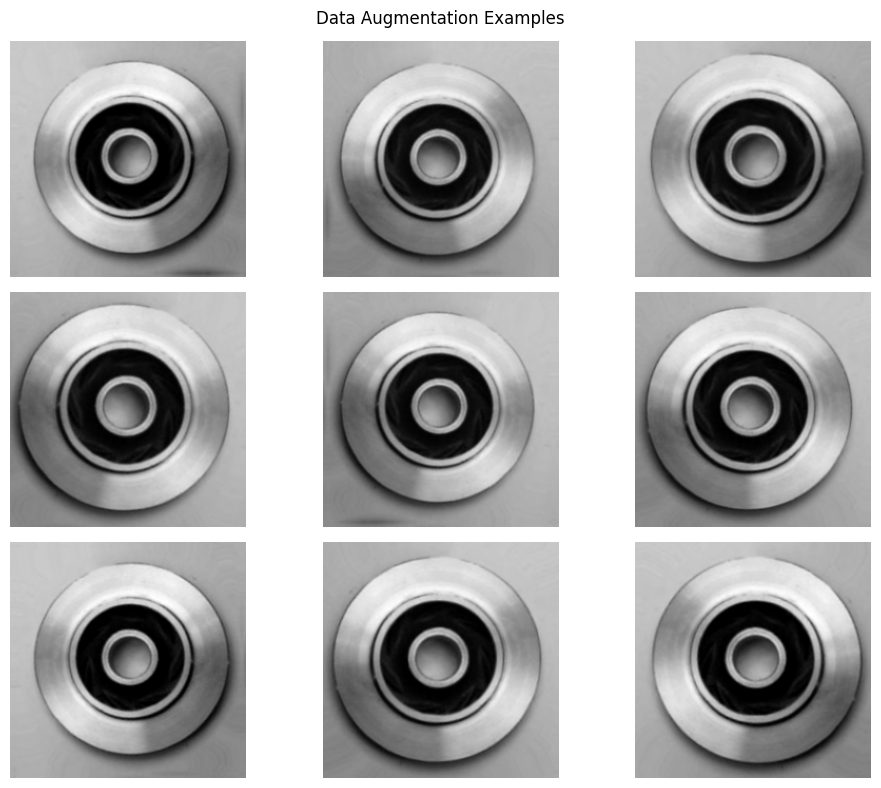

In [22]:
plt.figure(figsize=(10, 8))

for images, labels in train_dataset.take(1):
    image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(image, 0),
            training=True
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(
            tf.cast(
                augmented_image[0],
                tf.uint8
            )
        )
        plt.axis("off")

plt.suptitle("Data Augmentation Examples")
plt.tight_layout()
plt.show()

In [23]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Data Augmentation
    data_augmentation,

    # Normalization
    layers.Rescaling(1.0 / 255),

    # Convolution Block 1
    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Convolution Block 2
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Convolution Block 3
    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    # Reduce feature maps
    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.40),

    # Dense Layer
    layers.Dense(
        64,
        activation="relu"
    ),

    # Binary Output
    layers.Dense(
        1,
        activation="sigmoid"
    )
])

print("✅ CNN Model Created")

✅ CNN Model Created


In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("✅ Model compiled successfully")

✅ Model compiled successfully


In [27]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [29]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

print("✅ Callbacks ready")

✅ Callbacks ready


In [30]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.5600 - loss: 0.6893 - precision: 0.5612 - recall: 0.9879 - val_accuracy: 0.5897 - val_loss: 0.6814 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.5608 - loss: 0.6856 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6788 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5608 - loss: 0.6824 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6696 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.5841 - loss: 0.6604 - precision: 0.5762 - recall: 0.9765 - val_accuracy: 0.6478 - val_loss: 0.6542 - val_precision: 0.6646 - val_recall: 0.8133 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - a

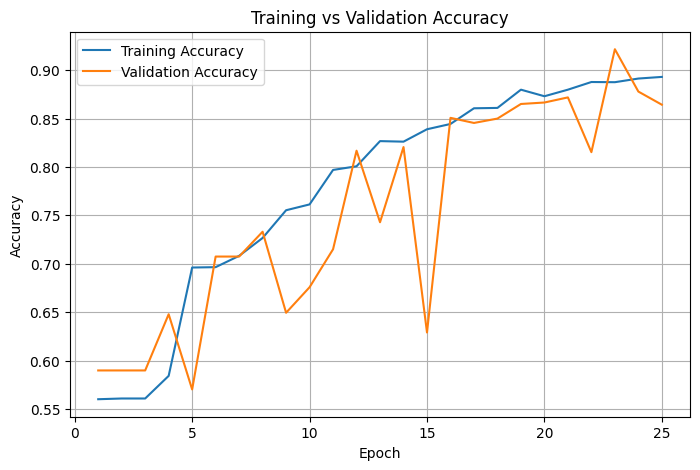

In [31]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

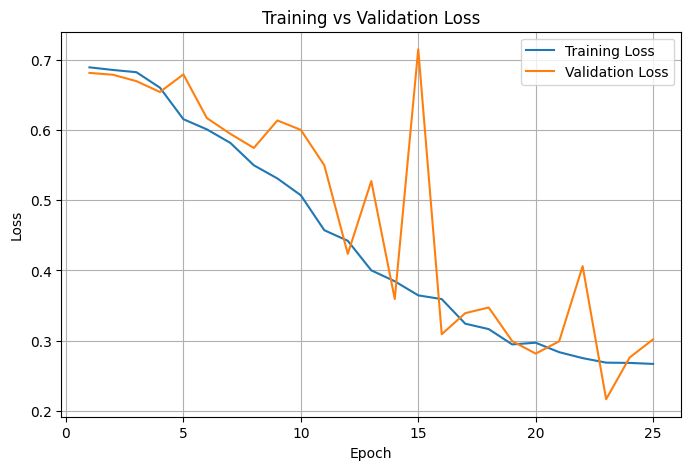

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
print("Maximum Epochs:", 25)
print("Epochs Actually Completed:", len(history.history["loss"]))

if len(history.history["loss"]) < 25:
    print("✅ Early Stopping Activated")
else:
    print("Training completed all 25 epochs")

Maximum Epochs: 25
Epochs Actually Completed: 25
Training completed all 25 epochs


In [35]:
test_results = model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True
)

print("\nFINAL TEST RESULTS")
print("-" * 40)

for name, value in test_results.items():
    print(f"{name.capitalize():12}: {value:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9259 - loss: 0.2228 - precision: 0.9608 - recall: 0.9205

FINAL TEST RESULTS
----------------------------------------
Accuracy    : 0.9259
Loss        : 0.2228
Precision   : 0.9608
Recall      : 0.9205


In [36]:
import numpy as np

probabilities = model.predict(
    test_dataset,
    verbose=1
).flatten()

predictions = (
    probabilities >= 0.50
).astype(int)

print("✅ Predictions generated")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
✅ Predictions generated


In [37]:
actual_labels = np.concatenate([
    labels.numpy().flatten()
    for _, labels in test_dataset
]).astype(int)

print("Total actual labels:", len(actual_labels))
print("Total predictions:", len(predictions))

Total actual labels: 715
Total predictions: 715


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    actual_labels,
    predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[245  17]
 [ 36 417]]


In [39]:
tn, fp, fn, tp = cm.ravel()

print("\nCONFUSION MATRIX VALUES")
print("-" * 35)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)


CONFUSION MATRIX VALUES
-----------------------------------
True Negative : 245
False Positive: 17
False Negative: 36
True Positive : 417


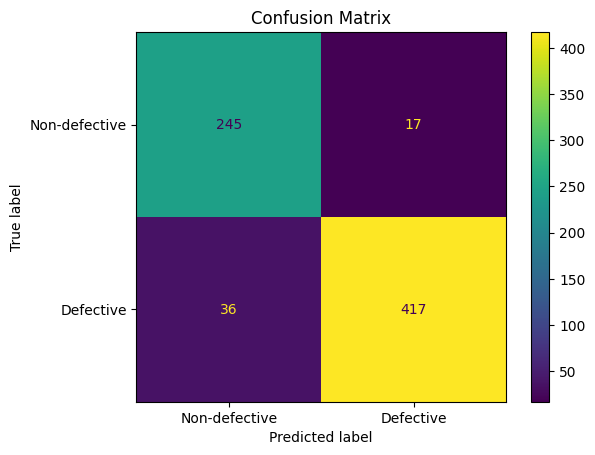

In [40]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Non-defective",
        "Defective"
    ]
)

disp.plot(values_format="d")

plt.title("Confusion Matrix")
plt.show()

In [41]:
from sklearn.metrics import classification_report

report = classification_report(
    actual_labels,
    predictions,
    target_names=[
        "Non-defective",
        "Defective"
    ],
    digits=4
)

print("CLASSIFICATION REPORT")
print("-" * 60)
print(report)

CLASSIFICATION REPORT
------------------------------------------------------------
               precision    recall  f1-score   support

Non-defective     0.8719    0.9351    0.9024       262
    Defective     0.9608    0.9205    0.9402       453

     accuracy                         0.9259       715
    macro avg     0.9164    0.9278    0.9213       715
 weighted avg     0.9282    0.9259    0.9264       715



In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(actual_labels, predictions)
recall = recall_score(actual_labels, predictions)
f1 = f1_score(actual_labels, predictions)

print("DEFECTIVE CLASS METRICS")
print("-" * 35)
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

DEFECTIVE CLASS METRICS
-----------------------------------
Precision : 0.9608
Recall    : 0.9205
F1 Score  : 0.9402


In [44]:
import os
import random

test_images = []

for class_name in ["ok_front", "def_front"]:
    folder = os.path.join(TEST_PATH, class_name)

    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)

        if os.path.isfile(file_path):
            test_images.append(
                (file_path, class_name)
            )

random.seed(42)
random.shuffle(test_images)

selected_images = test_images[:5]

print("Selected unseen images:", len(selected_images))

Selected unseen images: 5


Image 1
----------------------------------------
Actual      : Defective
Prediction  : Defective
Probability : 67.41%
Action      : Send for manual inspection

Image 2
----------------------------------------
Actual      : Non-defective
Prediction  : Non-defective
Probability : 85.99%
Action      : Pass

Image 3
----------------------------------------
Actual      : Defective
Prediction  : Defective
Probability : 77.26%
Action      : Send for manual inspection

Image 4
----------------------------------------
Actual      : Non-defective
Prediction  : Non-defective
Probability : 94.78%
Action      : Pass

Image 5
----------------------------------------
Actual      : Defective
Prediction  : Defective
Probability : 73.07%
Action      : Send for manual inspection



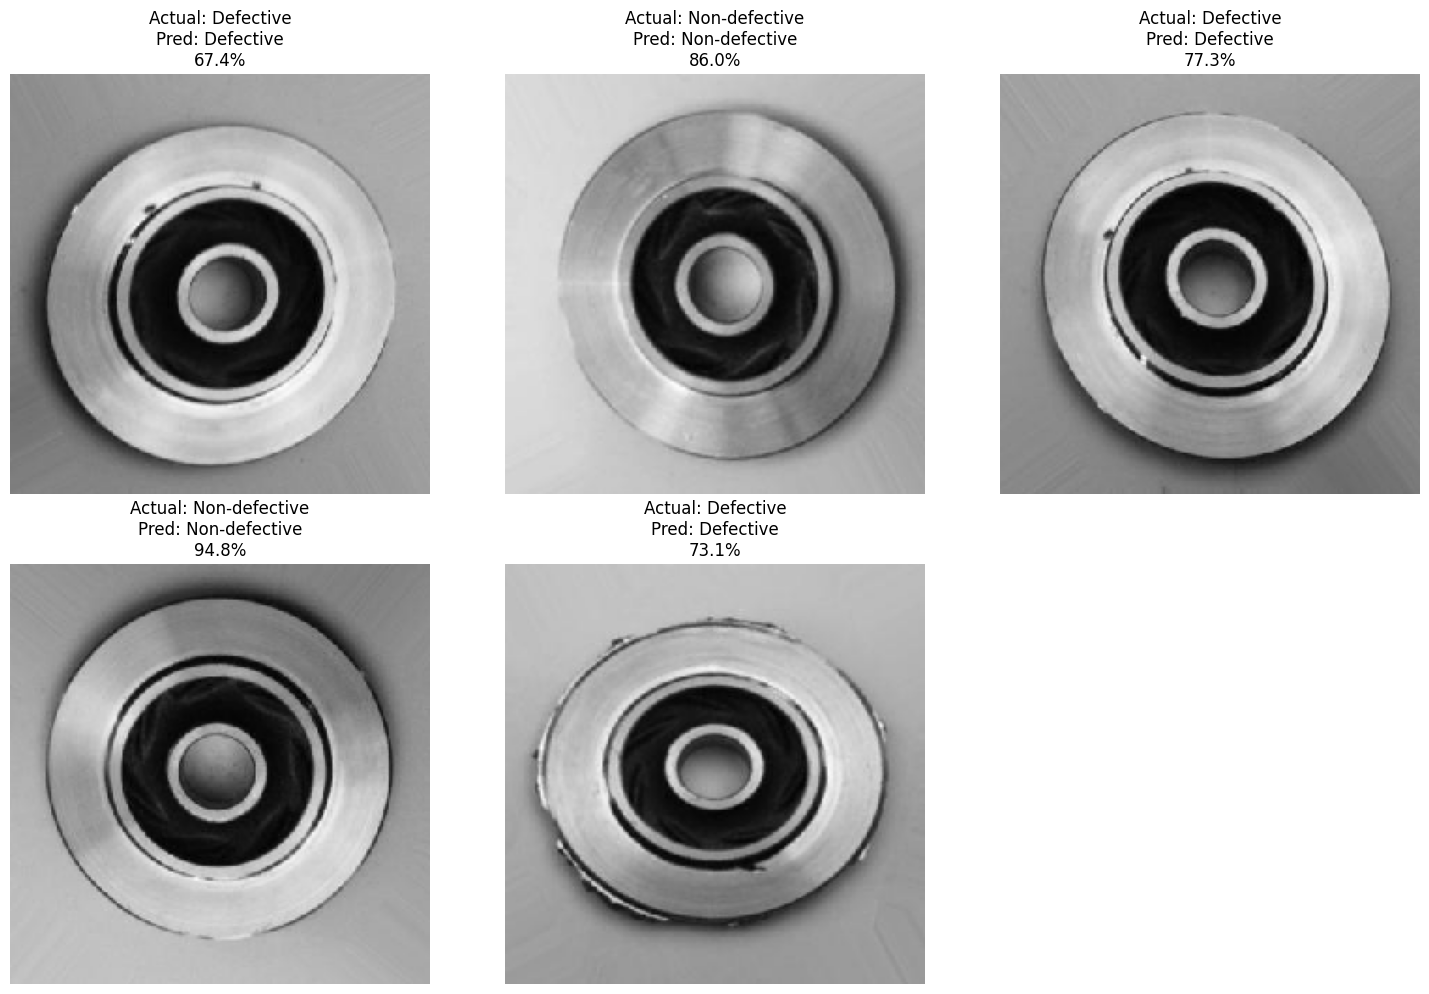

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import load_img, img_to_array

plt.figure(figsize=(15, 10))

for i, (image_path, actual_class) in enumerate(selected_images):

    # Load image
    img = load_img(
        image_path,
        target_size=IMAGE_SIZE
    )

    img_array = img_to_array(img)

    # Add batch dimension
    img_batch = np.expand_dims(
        img_array,
        axis=0
    )

    # Model prediction
    defect_probability = float(
        model.predict(
            img_batch,
            verbose=0
        )[0][0]
    )

    # Threshold = 0.50
    if defect_probability >= 0.50:
        predicted_class = "Defective"
        confidence = defect_probability
        action = "Send for manual inspection"

    else:
        predicted_class = "Non-defective"
        confidence = 1 - defect_probability
        action = "Pass"

    # Actual class
    if actual_class == "def_front":
        actual_label = "Defective"
    else:
        actual_label = "Non-defective"

    print(f"Image {i+1}")
    print("-" * 40)
    print("Actual      :", actual_label)
    print("Prediction  :", predicted_class)
    print(f"Probability : {confidence * 100:.2f}%")
    print("Action      :", action)
    print()

    # Display
    plt.subplot(2, 3, i + 1)

    plt.imshow(img)

    plt.title(
        f"Actual: {actual_label}\n"
        f"Pred: {predicted_class}\n"
        f"{confidence * 100:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## Design Decision Table

| Design Decision | Selected Value | Reason |
|---|---|---|
| Image size | 224 × 224 | Balance between image detail and computation |
| Problem type | Binary classification | Two output classes: non-defective and defective |
| Model type | CNN | CNN is suitable for image classification |
| Conv filters | 32, 64, 128 | Learn increasingly complex visual features |
| Kernel size | 3 × 3 | Efficient local feature extraction |
| Hidden activation | ReLU | Efficient and commonly used in CNN hidden layers |
| Pooling | MaxPooling2D | Reduces feature-map dimensions and computation |
| Global pooling | GlobalAveragePooling2D | Reduces trainable parameters compared with Flatten |
| Output activation | Sigmoid | Produces a probability between 0 and 1 |
| Optimizer | Adam | Adaptive and beginner-friendly |
| Learning rate | 0.001 | Standard starting learning rate for Adam |
| Loss function | Binary Cross-Entropy | Suitable for binary classification |
| Batch size | 32 | Good balance between memory and training stability |
| Epochs | Maximum 25 | Provides enough training with EarlyStopping protection |
| Dropout | 0.40 | Helps reduce overfitting |
| Augmentation | Flip, rotation, zoom, contrast | Improves robustness to real-world image variations |
| Metrics | Accuracy, Precision, Recall | Measures overall performance and defect detection quality |

\## Architecture Design Explanation

The CNN uses three convolutional layers with 32, 64, and 128 filters. The number of filters increases in deeper layers so that the model can learn increasingly complex visual features.

ReLU activation is used in the hidden layers because it is computationally efficient and allows the model to learn non-linear patterns.

MaxPooling2D is used after each convolution layer to reduce the spatial dimensions of the feature maps and lower computational cost.

GlobalAveragePooling2D is used instead of Flatten because it significantly reduces the number of trainable parameters.

A dropout rate of 0.40 is applied to reduce overfitting.

The final output layer contains one neuron with sigmoid activation because this is a binary classification problem.

## Training and Validation Curve Observations

The training accuracy improved steadily during the training process and reached approximately 89%.

The validation accuracy also improved and reached approximately 86% by the end of training.

There was no very large gap between training and validation accuracy, which indicates that the model was able to generalize reasonably well.

The validation performance showed some fluctuations during training, but there was no strong evidence of severe overfitting.

The model completed all 25 epochs, so EarlyStopping did not stop the training early. However, the best-performing weights were restored at the end of training.

The training loss decreased over time, while the validation loss showed some variation. Overall, the model learned useful features for distinguishing defective and non-defective casting products.

## Conclusion

In this mini project, a Convolutional Neural Network was implemented for binary image classification of casting products.

The model classified images into two classes:

- Class 0: Non-defective
- Class 1: Defective

The CNN used three convolution layers with 32, 64, and 128 filters, ReLU activation, MaxPooling2D, GlobalAveragePooling2D, Dropout, and a sigmoid output layer.

Data normalization and augmentation were used to improve training stability and model robustness. Adam optimizer with a learning rate of 0.001 and Binary Cross-Entropy loss were used for training.

Accuracy, precision, recall, F1-score, and the confusion matrix were used to evaluate model performance.

Recall for the defective class is especially important because a false negative means that an actually defective product could be incorrectly classified as non-defective and pass quality inspection.

Overall, the CNN successfully learned useful visual patterns for automated casting-product defect classification.

In [47]:
bonus_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    # Changed from 0.40 to 0.20
    layers.Dropout(0.20),

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

bonus_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("✅ Bonus model created with Dropout = 0.20")

✅ Bonus model created with Dropout = 0.20


In [48]:
bonus_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

bonus_history = bonus_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=bonus_callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 64ms/step - accuracy: 0.5608 - loss: 0.6886 - precision: 0.5610 - recall: 0.9970 - val_accuracy: 0.5897 - val_loss: 0.6810 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5594 - loss: 0.6847 - precision: 0.5613 - recall: 0.9815 - val_accuracy: 0.5897 - val_loss: 0.6727 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5546 - loss: 0.6826 - precision: 0.5628 - recall: 0.9214 - val_accuracy: 0.5897 - val_loss: 0.6713 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.5907 - loss: 0.6666 - precision: 0.5882 - recall: 0.9005 - val_accuracy: 0.8228 - val_loss: 0.6051 - val_precision: 0.8090 - val_recall: 0.9156 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - a

In [49]:
bonus_results = bonus_model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True
)

print("\nBONUS MODEL TEST RESULTS")
print("-" * 40)

for name, value in bonus_results.items():
    print(f"{name.capitalize():12}: {value:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9427 - loss: 0.1781 - precision: 0.9459 - recall: 0.9647

BONUS MODEL TEST RESULTS
----------------------------------------
Accuracy    : 0.9427
Loss        : 0.1781
Precision   : 0.9459
Recall      : 0.9647


In [50]:
# Evaluate both models using the same test dataset

original_results = model.evaluate(
    test_dataset,
    verbose=0,
    return_dict=True
)

bonus_results = bonus_model.evaluate(
    test_dataset,
    verbose=0,
    return_dict=True
)

print("ORIGINAL vs BONUS MODEL")
print("=" * 60)

print(f"{'Metric':<15} {'Original (0.40)':<20} {'Bonus (0.20)':<20}")
print("-" * 60)

for metric in ["accuracy", "precision", "recall", "loss"]:
    print(
        f"{metric.capitalize():<15} "
        f"{original_results[metric]:<20.4f} "
        f"{bonus_results[metric]:<20.4f}"
    )

ORIGINAL vs BONUS MODEL
Metric          Original (0.40)      Bonus (0.20)        
------------------------------------------------------------
Accuracy        0.9259               0.9427              
Precision       0.9608               0.9459              
Recall          0.9205               0.9647              
Loss            0.2228               0.1781              


In [51]:
original_accuracy = original_results["accuracy"]
bonus_accuracy = bonus_results["accuracy"]

print("\nBONUS EXPERIMENT")
print("-" * 50)

print("Original Design : Dropout = 0.40")
print("Changed Design  : Dropout = 0.20")
print("Reason for Change:")
print("To examine whether reducing dropout improves model learning and test performance.")

print(f"\nOriginal Accuracy: {original_accuracy:.4f}")
print(f"New Accuracy     : {bonus_accuracy:.4f}")

if bonus_accuracy > original_accuracy:
    print(
        "\nObservation: Reducing dropout from 0.40 to 0.20 "
        "improved test accuracy."
    )
elif bonus_accuracy < original_accuracy:
    print(
        "\nObservation: Reducing dropout from 0.40 to 0.20 "
        "reduced test accuracy. The original dropout provided better regularization."
    )
else:
    print(
        "\nObservation: Both dropout values produced approximately "
        "the same test accuracy."
    )


BONUS EXPERIMENT
--------------------------------------------------
Original Design : Dropout = 0.40
Changed Design  : Dropout = 0.20
Reason for Change:
To examine whether reducing dropout improves model learning and test performance.

Original Accuracy: 0.9259
New Accuracy     : 0.9427

Observation: Reducing dropout from 0.40 to 0.20 improved test accuracy.


In [52]:
model.save("/content/task14_cnn_model.keras")

print("✅ Final CNN model saved")

✅ Final CNN model saved


In [53]:
bonus_model.save("/content/task14_bonus_model.keras")

print("✅ Bonus model saved")

✅ Bonus model saved


In [54]:
import os

SUBMISSION_DIR = "/content/Task_14_Submission"

os.makedirs(SUBMISSION_DIR, exist_ok=True)

print("✅ Submission folder created")

✅ Submission folder created


In [55]:
!cp /content/task14_cnn_model.keras /content/Task_14_Submission/
!cp /content/task14_bonus_model.keras /content/Task_14_Submission/

print("✅ Models copied")

✅ Models copied


In [56]:
import os

SUBMISSION_DIR = "/content/Task_14_Submission"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

readme_content = """
# Task 14 - Binary Image Classification Using CNN

## Project Title
Binary Image Classification Using a Convolutional Neural Network

## Objective
The objective of this project is to build a Convolutional Neural Network (CNN)
that classifies casting product images into two categories:

- Class 0: Non-defective (`ok_front`)
- Class 1: Defective (`def_front`)

The project also documents the reasoning behind the major CNN architecture
and training design choices.

---

## Dataset

Dataset:
Casting Product Image Data for Quality Inspection

Source:
Kaggle - Real Life Industrial Dataset of Casting Product

Classes:

- `ok_front`  -> Non-defective -> Class 0
- `def_front` -> Defective     -> Class 1

Dataset contains separate training and testing folders.

The training dataset was further divided into:

- 80% Training
- 20% Validation

The original test dataset was kept separate for final evaluation.

---

## Technology Stack

- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab
- NVIDIA Tesla T4 GPU

---

## Hardware Used

The project was trained using:

- GPU: NVIDIA Tesla T4
- TensorFlow GPU acceleration
- Google Colab environment

GPU acceleration was used to reduce CNN training time.

---

## Input Configuration

Image Size:

224 x 224 x 3

Batch Size:

32

The image size of 224 x 224 was selected because it provides enough visual
detail while keeping memory usage and computation manageable.

---

## Data Normalization

Image pixel values originally range from 0 to 255.

The following normalization was used:

Rescaling(1.0 / 255)

This converts pixel values approximately to the range 0 to 1 and improves
training stability.

---

## Data Augmentation

The training dataset uses mild augmentation:

- Random Horizontal Flip
- Random Rotation: 0.05
- Random Zoom: 0.10
- Random Contrast: 0.10

Data augmentation improves model robustness against small variations in
orientation, camera position, zoom and lighting.

Augmentation is applied only during model training.

---

## CNN Architecture

The CNN architecture is:

Input: 224 x 224 x 3

Data Augmentation

Rescaling 1/255

Conv2D
- Filters: 32
- Kernel: 3 x 3
- Activation: ReLU

MaxPooling2D

Conv2D
- Filters: 64
- Kernel: 3 x 3
- Activation: ReLU

MaxPooling2D

Conv2D
- Filters: 128
- Kernel: 3 x 3
- Activation: ReLU

MaxPooling2D

GlobalAveragePooling2D

Dropout
- Rate: 0.40

Dense
- Units: 64
- Activation: ReLU

Output Dense Layer
- Units: 1
- Activation: Sigmoid

---

## Architecture Design Choices

### CNN Filters

32 -> 64 -> 128

The number of filters increases in deeper layers so the CNN can learn
increasingly complex visual patterns.

### Kernel Size

3 x 3 kernels were selected because they efficiently extract local visual
features such as edges, textures and defect patterns.

### ReLU Activation

ReLU is used in hidden layers because it is computationally efficient and
works well for CNN image classification.

### Max Pooling

MaxPooling2D reduces feature-map dimensions and computational requirements
while preserving important activations.

### Global Average Pooling

GlobalAveragePooling2D was selected instead of a large Flatten layer to
reduce the number of trainable parameters.

### Dropout

Dropout = 0.40

Dropout helps reduce overfitting by randomly disabling neurons during
training.

### Output Layer

Dense(1, activation="sigmoid")

Sigmoid produces a probability between 0 and 1 and is suitable for binary
classification.

---

## Training Configuration

Optimizer:
Adam

Learning Rate:
0.001

Loss Function:
Binary Cross-Entropy

Batch Size:
32

Maximum Epochs:
25

Metrics:

- Accuracy
- Precision
- Recall

---

## Callbacks

### EarlyStopping

- Monitor: Validation Loss
- Patience: 5
- Restore Best Weights: True

EarlyStopping prevents unnecessary training when validation performance
stops improving.

### ReduceLROnPlateau

- Monitor: Validation Loss
- Factor: 0.5
- Patience: 2

This reduces the learning rate when validation improvement slows down.

---

## Training Results

During training:

- Training accuracy improved significantly.
- Final training accuracy was approximately 89%.
- Validation accuracy reached approximately 86%.
- Training and validation accuracy remained reasonably close.
- No severe overfitting was observed.
- The model completed all 25 epochs.
- Best-performing model weights were restored after training.

Exact final test values are available in the Jupyter Notebook output.

---

## Model Evaluation

The model was evaluated using:

- Test Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- True Negatives
- False Positives
- False Negatives
- True Positives

---

## Importance of Recall

Recall for the defective class is particularly important.

A False Negative means:

Actual Defective Product
        |
        v
Predicted Non-defective

This is dangerous in quality inspection because a defective product could
incorrectly pass inspection.

Therefore, detecting as many actual defective products as possible is an
important objective of the model.

---

## Unseen Image Testing

At least five unseen images from the test dataset were evaluated.

For each image, the system reports:

- Actual Class
- Predicted Class
- Prediction Probability
- Recommended Action

For defective predictions:

Action: Send for manual inspection

For non-defective predictions:

Action: Pass

---

## Bonus Experiment

One design choice was changed:

Original Dropout:
0.40

Changed Dropout:
0.20

Reason:

The experiment investigates whether reducing dropout allows the model to
learn more information and improve classification performance.

The original and modified models were compared using the same test dataset.

Metrics compared:

- Accuracy
- Precision
- Recall
- Loss

Exact comparison results are available in the notebook.

---

## Design Decision Summary

| Design Decision | Selected Value |
|---|---|
| Image Size | 224 x 224 |
| Problem Type | Binary Classification |
| Model Type | CNN |
| Conv Filters | 32, 64, 128 |
| Kernel Size | 3 x 3 |
| Hidden Activation | ReLU |
| Pooling | MaxPooling2D |
| Global Pooling | GlobalAveragePooling2D |
| Output Activation | Sigmoid |
| Optimizer | Adam |
| Learning Rate | 0.001 |
| Loss Function | Binary Cross-Entropy |
| Batch Size | 32 |
| Maximum Epochs | 25 |
| Dropout | 0.40 |
| Augmentation | Flip, Rotation, Zoom, Contrast |
| Metrics | Accuracy, Precision, Recall |

---

## Files Included in Submission

The final submission package may contain:

1. `Task_14_Binary_Image_Classification_CNN.ipynb`
2. `README.md`
3. `task14_cnn_model.keras`
4. `task14_bonus_model.keras`
5. `casting_dataset/`

The original downloaded dataset ZIP and Google Colab `sample_data` folder
are intentionally excluded.

---

## Conclusion

A Convolutional Neural Network was successfully implemented for automated
casting product defect classification.

The CNN learned visual features using three convolutional layers with
increasing filter sizes. Data augmentation, normalization, dropout,
EarlyStopping and learning-rate reduction were used to improve robustness
and generalization.

The model was evaluated using accuracy, precision, recall, F1-score and a
confusion matrix.

For industrial quality inspection, defective-class recall is especially
important because false negatives can allow defective products to pass
inspection.

The project demonstrates the complete workflow of designing, training,
evaluating and comparing a binary CNN image classifier.
"""

readme_path = os.path.join(
    SUBMISSION_DIR,
    "README.md"
)

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("✅ README created successfully")
print("Location:", readme_path)

✅ README created successfully
Location: /content/Task_14_Submission/README.md


In [57]:
import shutil
import os

dataset_source = "/content/casting_dataset"
dataset_destination = "/content/Task_14_Submission/casting_dataset"

if os.path.exists(dataset_destination):
    shutil.rmtree(dataset_destination)

shutil.copytree(
    dataset_source,
    dataset_destination,
    ignore=shutil.ignore_patterns(
        "*.zip",
        "__pycache__"
    )
)

print("✅ Dataset copied to submission folder")

✅ Dataset copied to submission folder


In [59]:
import shutil

zip_path = shutil.make_archive(
    "/content/Task_14_Submission",
    "zip",
    "/content/Task_14_Submission"
)

print("✅ Final submission ZIP created")
print("ZIP:", zip_path)

✅ Final submission ZIP created
ZIP: /content/Task_14_Submission.zip


In [60]:
from google.colab import files

files.download(
    "/content/Task_14_Submission.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>